In [1]:
import os
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


In [3]:
class PatchCamH5Dataset(Dataset):
    def __init__(self, x_path, y_path, transform=None):
        self.x_file = h5py.File(x_path, "r")
        self.y_file = h5py.File(y_path, "r")
        self.X = self.x_file["x"]
        self.y = self.y_file["y"]
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        if self.transform:
            img = self.transform(img)
        return img


In [4]:
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])


In [5]:
DATA_DIR = "/kaggle/input/patchcam-dataset"

dataset = PatchCamH5Dataset(
    x_path=f"{DATA_DIR}/camelyonpatch_level_2_split_train_x.h5",
    y_path=f"{DATA_DIR}/camelyonpatch_level_2_split_train_y.h5",
    transform=transform
)

gan_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print("Total samples:", len(dataset))


Total samples: 262144


In [6]:
img = dataset[0]
print(img.shape, img.min().item(), img.max().item())


torch.Size([3, 96, 96]) -1.0 1.0


In [7]:
class Generator(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 6, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, 6, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [9]:
def gradient_penalty(D, real, fake):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    interp = eps * real + (1 - eps) * fake
    interp.requires_grad_(True)

    scores = D(interp)
    grads = torch.autograd.grad(
        outputs=scores,
        inputs=interp,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grads = grads.view(B, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


In [10]:
Z_DIM = 128
lambda_gp = 20
n_critic = 2
EPOCHS = 10

G = Generator(Z_DIM).to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.0, 0.9))


In [11]:
os.makedirs("/kaggle/working/samples", exist_ok=True)
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

def save_samples(epoch):
    z = torch.randn(16, Z_DIM, 1, 1, device=device)
    with torch.no_grad():
        fake = G(z).cpu()
    grid = utils.make_grid(fake, nrow=4, normalize=True)
    utils.save_image(grid, f"/kaggle/working/samples/epoch_{epoch}.png")

def save_checkpoint(epoch):
    torch.save({
        "G": G.state_dict(),
        "D": D.state_dict()
    }, f"/kaggle/working/checkpoints/epoch_{epoch}.pth")


In [12]:
for epoch in range(1, EPOCHS + 1):
    for batch_idx, real_imgs in enumerate(gan_loader):
        real_imgs = real_imgs.to(device)

        # ---- Train Critic ----
        for _ in range(n_critic):
            z = torch.randn(real_imgs.size(0), Z_DIM, 1, 1, device=device)
            fake_imgs = G(z)

            real_score = D(real_imgs)
            fake_score = D(fake_imgs.detach())

            gp = gradient_penalty(D, real_imgs, fake_imgs)
            loss_D = fake_score.mean() - real_score.mean() + lambda_gp * gp

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

        # ---- Train Generator ----
        z = torch.randn(real_imgs.size(0), Z_DIM, 1, 1, device=device)
        fake_imgs = G(z)
        loss_G = -D(fake_imgs).mean()

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    save_samples(epoch)
    save_checkpoint(epoch)
    print(f"Epoch [{epoch}/{EPOCHS}] | D: {loss_D.item():.3f} | G: {loss_G.item():.3f}")

print("Training completed safely.")


Epoch [1/10] | D: 0.014 | G: 0.263
Epoch [2/10] | D: 0.059 | G: 0.152
Epoch [3/10] | D: 0.036 | G: 0.072
Epoch [4/10] | D: 0.017 | G: 0.128
Epoch [5/10] | D: 0.000 | G: 0.141
Epoch [6/10] | D: -0.007 | G: 0.130
Epoch [7/10] | D: -0.010 | G: 0.122
Epoch [8/10] | D: -0.005 | G: 0.152
Epoch [9/10] | D: 0.006 | G: 0.123
Epoch [10/10] | D: -0.009 | G: 0.034
Training completed safely.


In [18]:
import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid

def show_generated_images(generator, n=16):
    generator.eval()

    z = torch.randn(n, Z_DIM, 1, 1, device=device)
    with torch.no_grad():
        fake_imgs = generator(z)

    # denormalize [-1,1] → [0,1]
    fake_imgs = fake_imgs * 0.5 + 0.5
    fake_imgs = fake_imgs.cpu()

    grid = make_grid(fake_imgs, nrow=int(n**0.5), padding=2)

    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("GAN-Generated PatchCam Samples", fontsize=14)
    plt.show()


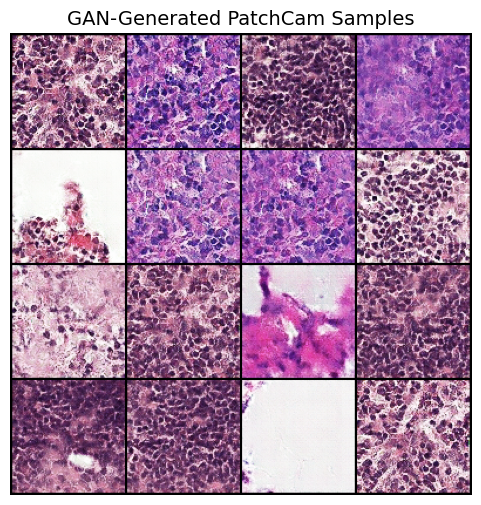

In [19]:
show_generated_images(G, n=16)


In [20]:
import matplotlib.pyplot as plt
import torch

def show_real_vs_gan(real_loader, generator, n=8):
    generator.eval()

    # ---- get real images ----
    real_imgs = next(iter(real_loader))
    real_imgs = real_imgs[:n].to(device)

    # ---- generate fake images ----
    z = torch.randn(n, Z_DIM, 1, 1, device=device)
    with torch.no_grad():
        fake_imgs = generator(z)

    # ---- denormalize from [-1,1] → [0,1] ----
    real_imgs = real_imgs * 0.5 + 0.5
    fake_imgs = fake_imgs * 0.5 + 0.5

    real_imgs = real_imgs.cpu()
    fake_imgs = fake_imgs.cpu()

    # ---- plotting ----
    fig, axes = plt.subplots(2, n, figsize=(n * 2.2, 4.5))

    for i in range(n):
        axes[0, i].imshow(real_imgs[i].permute(1, 2, 0))
        axes[1, i].imshow(fake_imgs[i].permute(1, 2, 0))
        axes[0, i].axis("off")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Real", fontsize=12)
    axes[1, 0].set_ylabel("GAN", fontsize=12)

    plt.suptitle(
        "Top: Real Patches | Bottom: GAN-Generated Patches",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


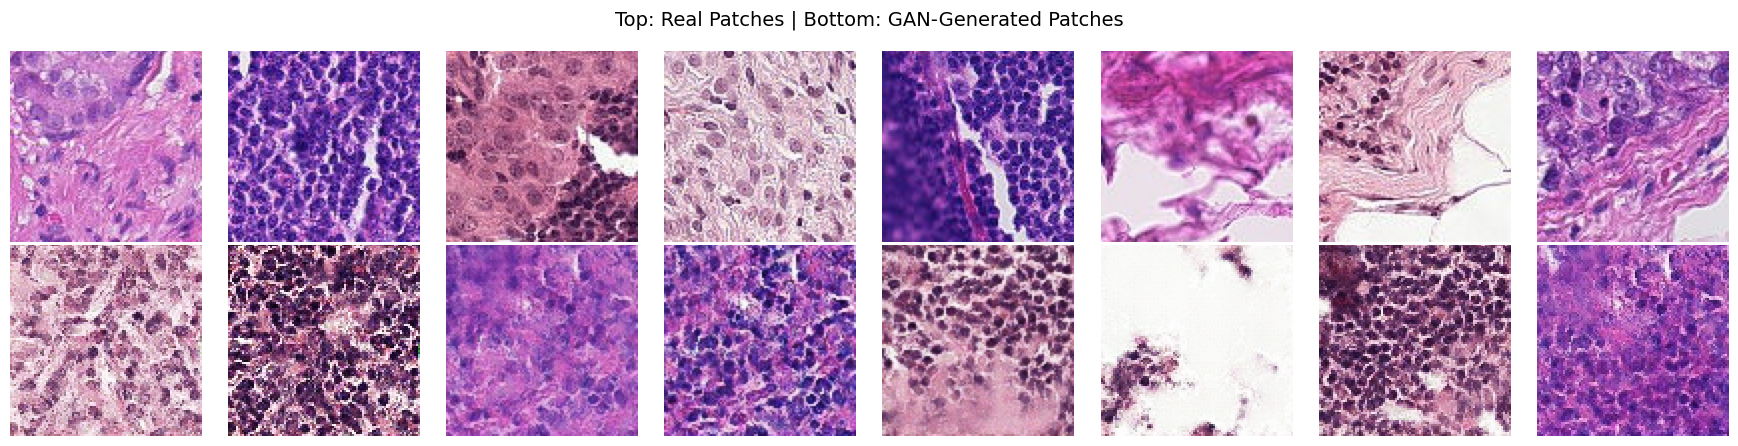

In [21]:
show_real_vs_gan(gan_loader, G, n=8)


In [24]:
import torch

@torch.no_grad()
def collect_images_fixed(dataloader, generator, device, num_samples=2048):
    generator.eval()

    real_imgs = []
    fake_imgs = []

    for real in dataloader:
        real = real.to(device)
        bs = real.size(0)

        # ✅ CORRECT latent shape for ConvTranspose2d generator
        z = torch.randn(bs, Z_DIM, 1, 1, device=device)
        fake = generator(z)

        real_imgs.append(real.cpu())
        fake_imgs.append(fake.cpu())

        if torch.cat(real_imgs).size(0) >= num_samples:
            break

    real_imgs = torch.cat(real_imgs)[:num_samples]
    fake_imgs = torch.cat(fake_imgs)[:num_samples]

    return real_imgs, fake_imgs


REAL_IMGS, FAKE_IMGS = collect_images_fixed(
    gan_loader, G, device, num_samples=2048
)

print("REAL:", REAL_IMGS.shape)
print("FAKE:", FAKE_IMGS.shape)


REAL: torch.Size([2048, 3, 96, 96])
FAKE: torch.Size([2048, 3, 96, 96])


In [25]:
!pip install torch-fidelity


In [30]:
def to_uint8(imgs):
    """
    Convert GAN images to uint8 [0,255] as required by torch-fidelity
    """
    imgs = imgs.clamp(-1, 1)          # safety
    imgs = (imgs + 1) / 2             # [-1,1] -> [0,1]
    imgs = (imgs * 255).round()       # [0,255]
    imgs = imgs.to(torch.uint8)
    return imgs


REAL_IMGS_UINT8 = to_uint8(REAL_IMGS)
FAKE_IMGS_UINT8 = to_uint8(FAKE_IMGS)

print(REAL_IMGS_UINT8.dtype, REAL_IMGS_UINT8.min(), REAL_IMGS_UINT8.max())


torch.uint8 tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)


In [31]:
from torch.utils.data import Dataset

class TensorImageDataset(Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return self.images.size(0)

    def __getitem__(self, idx):
        return self.images[idx]


In [32]:
real_dataset = TensorImageDataset(REAL_IMGS_UINT8)
fake_dataset = TensorImageDataset(FAKE_IMGS_UINT8)


In [33]:
from torch_fidelity import calculate_metrics

fid_metrics = calculate_metrics(
    input1=real_dataset,
    input2=fake_dataset,
    cuda=torch.cuda.is_available(),
    fid=True,
    isc=False,
    kid=False,
    verbose=True
)

print("FID:", fid_metrics["frechet_inception_distance"])


Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting statistics from input 1
Processing samples                                                           
Extracting statistics from input 2
Processing samples                                                           


FID: 96.71932630530688


Frechet Inception Distance: 96.71932630530688


In [34]:
!pip install pytorch-msssim


In [35]:
from pytorch_msssim import ssim

# normalize to [0,1] if using tanh output
real_ssim = (REAL_IMGS + 1) / 2
fake_ssim = (FAKE_IMGS + 1) / 2

ssim_score = ssim(
    real_ssim,
    fake_ssim,
    data_range=1.0,
    size_average=True
)

print("SSIM:", ssim_score.item())


SSIM: 0.04348830506205559


In [36]:
def compute_mmd(x, y, kernel="rbf", sigma=1.0):
    x = x.view(x.size(0), -1)
    y = y.view(y.size(0), -1)

    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0).expand_as(xx)
    ry = yy.diag().unsqueeze(0).expand_as(yy)

    Kxx = torch.exp(- (rx.t() + rx - 2*xx) / (2*sigma**2))
    Kyy = torch.exp(- (ry.t() + ry - 2*yy) / (2*sigma**2))
    Kxy = torch.exp(- (rx.t() + ry - 2*xy) / (2*sigma**2))

    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()


mmd_score = compute_mmd(REAL_IMGS, FAKE_IMGS)
print("MMD:", mmd_score.item())


MMD: 0.0009794235229492188


In [37]:
# ===================== FINAL METRICS SUMMARY ===================== #

print("\n" + "="*60)
print("FINAL GAN EVALUATION METRICS")
print("="*60)

# ---- FID ----
# FID has no fixed maximum; lower is better, 0 is ideal
print(f"FID  : {fid_metrics['frechet_inception_distance']:.4f}  (Ideal: 0.0, Lower is better)")

# ---- SSIM ----
# SSIM ranges from 0 to 1
print(f"SSIM : {ssim_score.item():.4f} / 1.0000  (Higher is better)")

# ---- MMD ----
# MMD has no fixed maximum; 0 is ideal
print(f"MMD  : {mmd_score.item():.6f}  (Ideal: 0.0, Lower is better)")

print("="*60)



FINAL GAN EVALUATION METRICS
FID  : 96.7193  (Ideal: 0.0, Lower is better)
SSIM : 0.0435 / 1.0000  (Higher is better)
MMD  : 0.000979  (Ideal: 0.0, Lower is better)
